In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [6]:
df=pd.read_csv("../data/healthcare_cleaned.csv")
df.head()

,Patient_Name,Age,Gender,Blood_Type,Medical_Condition,Admission_Date,Doctor,Hospital,Insurance_Provider,Billing_Amount,Room_Number,Admission_Type,Discharge_Date,Medication,Test Results,Length_of_Stays,Age_Group
0,Bobby JacksOn,30,Male,B-,Cancer,31-01-2024,Samantha Davies,Sons and Miller,Blue Cross,18856.28,328,Urgent,02-02-2024,Paracetamol,Normal,2,18-34
1,LesLie TErRy,62,Male,A+,Obesity,20-08-2019,Tiffany Mitchell,Kim Inc,Medicare,33643.33,265,Emergency,26-08-2019,Ibuprofen,Inconclusive,6,50-64
2,DaNnY sMitH,76,Female,A-,Obesity,22-09-2022,Kevin Wells,Cook PLC,Aetna,27955.10,205,Emergency,07-10-2022,Aspirin,Normal,15,65+
3,andrEw waTtS,28,Female,O+,Diabetes,18-11-2020,Kathleen Hanna,"Hernandez Rogers and Vang,",Medicare,37909.78,450,Elective,18-12-2020,Ibuprofen,Abnormal,30,18-34
4,adrIENNE bEll,43,Female,AB+,Cancer,19-09-2022,Taylor Newton,White-White,Aetna,14238.32,458,Urgent,09-10-2022,Penicillin,Abnormal,20,35-49


In [7]:
df.shape
df.columns
df.info()
df.describe(include="all")
df.isnull().sum()
df.duplicated().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 54966 entries, 0 to 54965
Data columns (total 17 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Patient_Name        54966 non-null  object 
 1   Age                 54966 non-null  int64  
 2   Gender              54966 non-null  object 
 3   Blood_Type          54966 non-null  object 
 4   Medical_Condition   54966 non-null  object 
 5   Admission_Date      54966 non-null  object 
 6   Doctor              54966 non-null  object 
 7   Hospital            54966 non-null  object 
 8   Insurance_Provider  54966 non-null  object 
 9   Billing_Amount      54966 non-null  float64
 10  Room_Number         54966 non-null  int64  
 11  Admission_Type      54966 non-null  object 
 12  Discharge_Date      54966 non-null  object 
 13  Medication          54966 non-null  object 
 14  Test Results        54966 non-null  object 
 15  Length_of_Stays     54966 non-null  int64  
 16  Age_

np.int64(0)

In [8]:
df = df.drop_duplicates()

df["Admission_Date"] = pd.to_datetime(df["Admission_Date"], errors="coerce")
df["Discharge_Date"] = pd.to_datetime(df["Discharge_Date"], errors="coerce")

df["Billing_Amount"] = pd.to_numeric(df["Billing_Amount"], errors="coerce")

df["Length of Stay"] = (
    df["Discharge_Date"] - df["Admission_Date"]
).dt.days

df["Age_Group"] = pd.cut(
    df["Age"],
    bins=[0, 17, 34, 49, 64, 120],
    labels=["Under 18", "18-34", "35-49", "50-64", "65+"]
)

C:\Users\Prathmesh\AppData\Local\Temp\ipykernel_18816\1187528860.py:3: UserWarning: Parsing dates in %d-%m-%Y format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  df["Admission_Date"] = pd.to_datetime(df["Admission_Date"], errors="coerce")


In [9]:
# A. Patient DemoGraphics

In [10]:
df["Gender"].value_counts()
df["Age_Group"].value_counts() 

Age_Group
65+         16923
18-34       13485
50-64       12288
35-49       12154
Under 18      116
Name: count, dtype: int64

In [11]:
# Medical Condition

In [13]:
df["Medical_Condition"].value_counts()

Medical_Condition
Arthritis       9218
Diabetes        9216
Hypertension    9151
Obesity         9146
Cancer          9140
Asthma          9095
Name: count, dtype: int64

In [14]:
# Admission Patterns

In [16]:
df["Admission_Type"].value_counts()

Admission_Type
Elective     18473
Urgent       18391
Emergency    18102
Name: count, dtype: int64

In [17]:
#Billing Analysis

In [18]:
df.groupby("Medical_Condition")["Billing_Amount"].agg(
    ["count", "mean", "median", "sum"]
).sort_values("mean", ascending=False)

,count,mean,median,sum
Medical_Condition,,,,
Obesity,9146,25804.361860,26145.580,2.360067e+08
Diabetes,9216,25660.478627,25647.705,2.364870e+08
Asthma,9095,25633.461647,25628.410,2.331363e+08
Arthritis,9218,25511.783245,25599.185,2.351676e+08
Hypertension,9151,25503.058694,25281.630,2.333785e+08
Cancer,9140,25152.322927,24910.710,2.298922e+08


In [19]:
#Length of Stay

In [20]:
df.groupby("Medical_Condition")["Length of Stay"].mean().sort_values(
    ascending=False
)

Medical_Condition
Arthritis       17.227656
Diabetes        16.458690
Hypertension    16.418161
Asthma          16.053531
Obesity         14.066630
Cancer          11.832529
Name: Length of Stay, dtype: float64

In [21]:
#Test Result

In [25]:
pd.crosstab(df["Medical_Condition"], df["Test Results"])

Test Results,Abnormal,Inconclusive,Normal
Medical_Condition,,,
Arthritis,3156,3062,3000
Asthma,2980,2999,3116
Cancer,3089,3033,3018
Diabetes,3131,3024,3061
Hypertension,2977,3068,3106
Obesity,3104,3012,3030


In [26]:
# Top Medical Condition

C:\Users\Prathmesh\AppData\Local\Temp\ipykernel_18816\627424836.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(


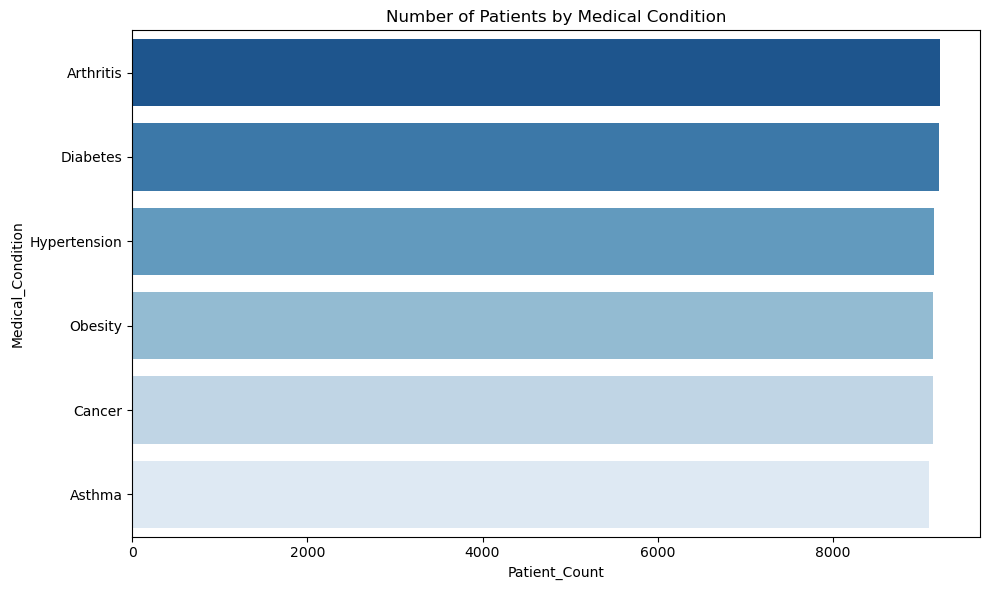

In [28]:
plt.figure(figsize=(10, 6))
sns.countplot(
    data=df,
    y="Medical_Condition",
    order=df["Medical_Condition"].value_counts().index,
    palette="Blues_r"
)
plt.title("Number of Patients by Medical Condition")
plt.xlabel("Patient_Count")
plt.ylabel("Medical_Condition")
plt.tight_layout()
plt.show()

In [29]:
#Average Billing Amount By Condition

C:\Users\Prathmesh\AppData\Local\Temp\ipykernel_18816\373199733.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=avg_bill, x="Billing_Amount", y="Medical_Condition", palette="viridis")


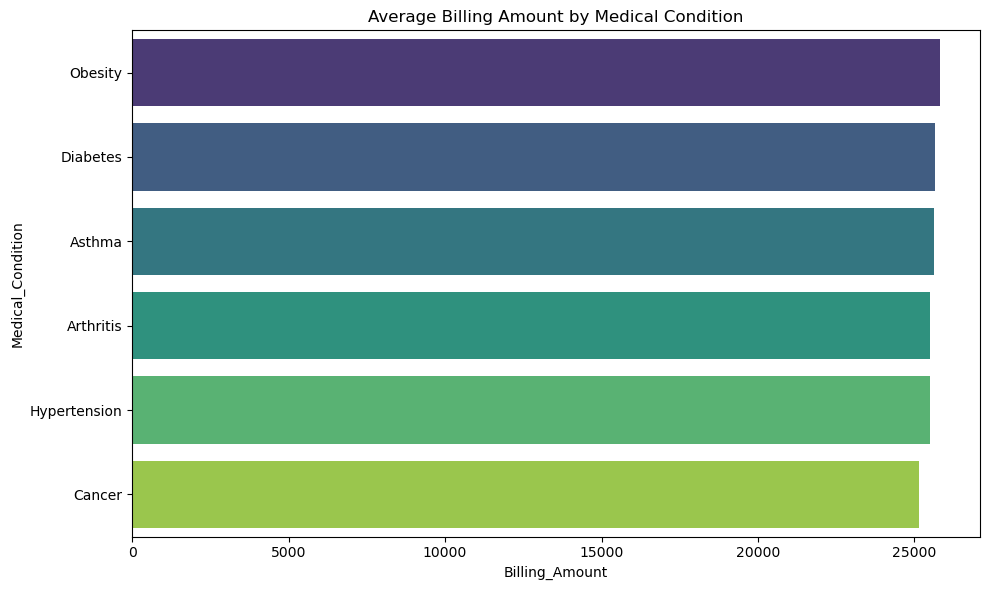

In [30]:
avg_bill = (
    df.groupby("Medical_Condition")["Billing_Amount"]
      .mean()
      .sort_values(ascending=False)
      .reset_index()
)

plt.figure(figsize=(10, 6))
sns.barplot(data=avg_bill, x="Billing_Amount", y="Medical_Condition", palette="viridis")
plt.title("Average Billing Amount by Medical Condition")
plt.tight_layout()
plt.show()

In [32]:
#Billing Amount By Admission Type

C:\Users\Prathmesh\AppData\Local\Temp\ipykernel_18816\1152295822.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x="Admission_Type", y="Billing_Amount", palette="Set2")


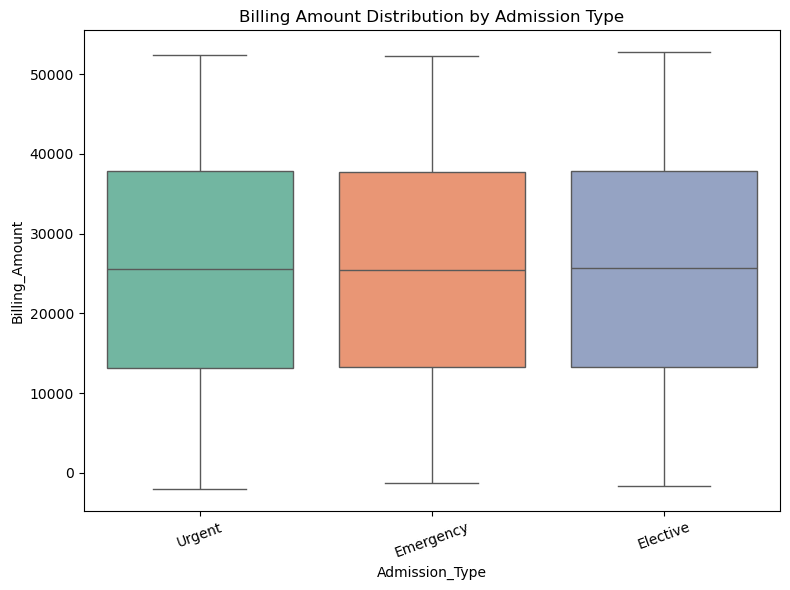

In [33]:
plt.figure(figsize=(8, 6))
sns.boxplot(data=df, x="Admission_Type", y="Billing_Amount", palette="Set2")
plt.title("Billing Amount Distribution by Admission Type")
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

In [34]:
#Average versus Billing amount

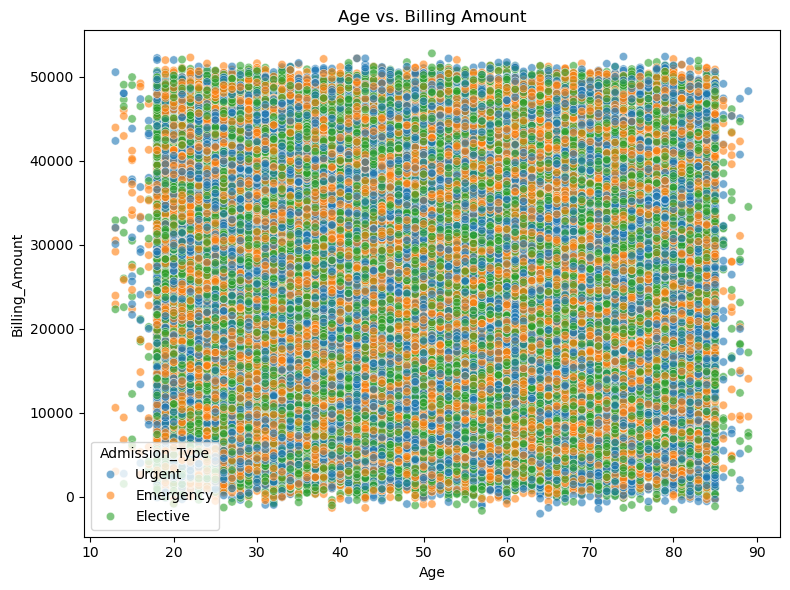

In [35]:
plt.figure(figsize=(8, 6))
sns.scatterplot(data=df, x="Age", y="Billing_Amount", hue="Admission_Type", alpha=0.6)
plt.title("Age vs. Billing Amount")
plt.tight_layout()
plt.show()

In [36]:
#Average Length By Stay By Condition

C:\Users\Prathmesh\AppData\Local\Temp\ipykernel_18816\3657466410.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=avg_stay, x="Length of Stay", y="Medical_Condition", palette="magma")


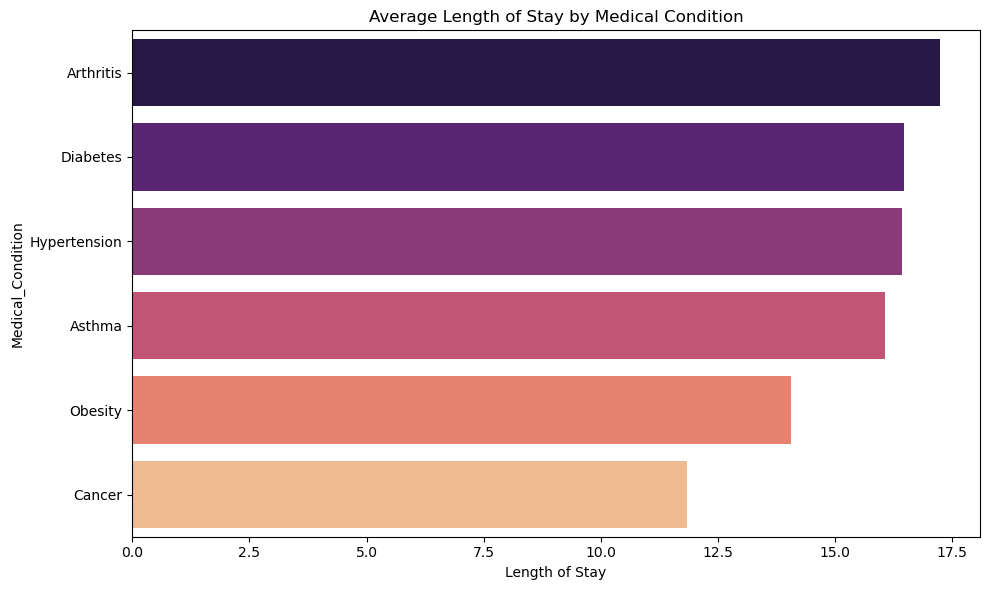

In [37]:
avg_stay = (
    df.groupby("Medical_Condition")["Length of Stay"]
      .mean()
      .sort_values(ascending=False)
      .reset_index()
)

plt.figure(figsize=(10, 6))
sns.barplot(data=avg_stay, x="Length of Stay", y="Medical_Condition", palette="magma")
plt.title("Average Length of Stay by Medical Condition")
plt.tight_layout()
plt.show()